# 04_improvement.ipynb

## Chuẩn bị dữ liệu

In [1]:
%run 00_core.ipynb

In [2]:
prior_items = load_csv(PATHS.data_file("prior_items.csv"))
train_items = load_csv(PATHS.data_file("train_items.csv"))
order_time = load_csv(PATHS.data_file("order_time.csv"))
product_catalog = load_csv(PATHS.data_file("product_catalog.csv"))

miner = RuleMiner()
fpgrowth_rules = miner.load_rules(PATHS.data_file("fpgrowth_rules.csv"))
formatter = RuleFormatter(product_catalog)
improver = RuleImprover()

## Weighted rules

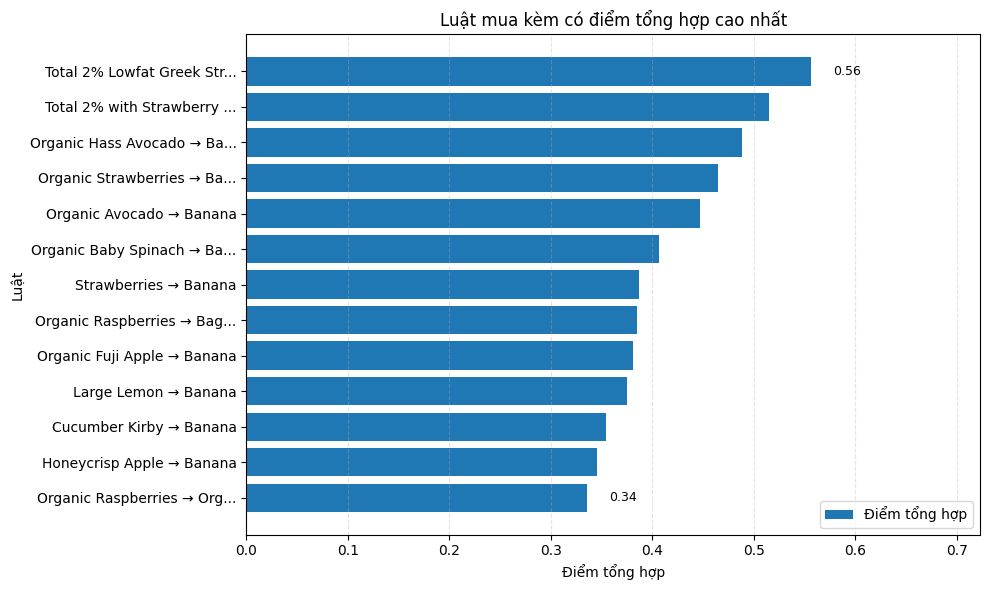

,Luật,Sản phẩm trong giỏ,Sản phẩm nên gợi ý,Support,Confidence,Lift,Điểm tổng hợp
0,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% with Strawberry Lowfat Greek Strained...,0.0031,0.4534,46.9179,0.5559
1,Total 2% with Strawberry Lowfat Greek Strained...,Total 2% with Strawberry Lowfat Greek Strained...,Total 2% Lowfat Greek Strained Yogurt With Blu...,0.0031,0.3158,46.9179,0.5148
41,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,0.0204,0.2975,2.5029,0.4885
74,Organic Strawberries → Bag of Organic Bananas,Organic Strawberries,Bag of Organic Bananas,0.0202,0.2384,2.0060,0.4642
61,Organic Avocado → Banana,Organic Avocado,Banana,0.0175,0.3082,2.0962,0.4472
116,Organic Strawberries → Banana,Organic Strawberries,Banana,0.0184,0.2172,1.4775,0.4292
115,Organic Baby Spinach → Banana,Organic Baby Spinach,Banana,0.0168,0.2174,1.4783,0.4063
92,Organic Baby Spinach → Bag of Organic Bananas,Organic Baby Spinach,Bag of Organic Bananas,0.0165,0.2130,1.7924,0.4010
66,Strawberries → Banana,Strawberries,Banana,0.0135,0.3030,2.0608,0.3868
40,Organic Raspberries → Bag of Organic Bananas,Organic Raspberries,Bag of Organic Bananas,0.0132,0.3014,2.5358,0.3848


In [3]:
weighted_rules = improver.add_weighted_score(
    fpgrowth_rules,
    prior_items,
)

weighted_table = weighted_rules.sort_values(
    "weighted_score",
    ascending=False,
).copy()
weighted_table["Luật"] = weighted_table.apply(formatter.rule_text, axis=1)
weighted_table["Sản phẩm trong giỏ"] = weighted_table["antecedents"].apply(
    formatter.itemset_text
)
weighted_table["Sản phẩm nên gợi ý"] = weighted_table["consequents"].apply(
    formatter.itemset_text
)

for column in ["support", "confidence", "lift", "weighted_score"]:
    weighted_table[column] = weighted_table[column].round(4)

weighted_table = weighted_table.rename(
    columns={
        "support": "Support",
        "confidence": "Confidence",
        "lift": "Lift",
        "weighted_score": "Điểm tổng hợp",
    }
)
weighted_table = weighted_table[
    [
        "Luật",
        "Sản phẩm trong giỏ",
        "Sản phẩm nên gợi ý",
        "Support",
        "Confidence",
        "Lift",
        "Điểm tổng hợp",
    ]
]
weighted_report = weighted_table.head(CFG.top_n)

save_csv(weighted_table, PATHS.table_file("weighted_rules.csv"))

PLOT.bar_horizontal(
    weighted_report,
    x="Luật",
    y="Điểm tổng hợp",
    title="Luật mua kèm có điểm tổng hợp cao nhất",
    filename="weighted_rules.png",
)

weighted_report

## Time-aware rules

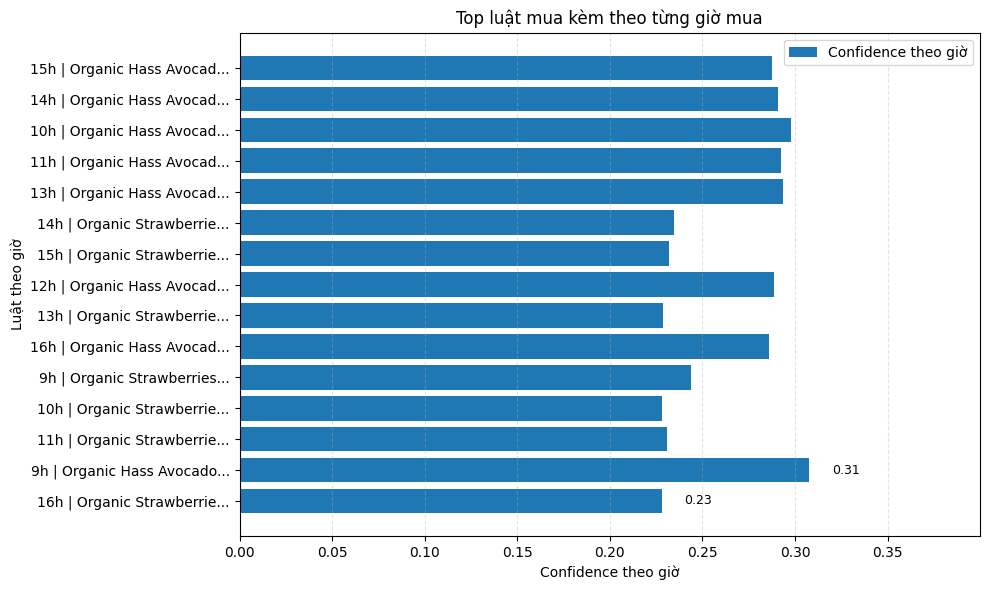

,Luật,Sản phẩm trong giỏ,Sản phẩm nên gợi ý,Giờ mua,Support theo giờ,Confidence theo giờ,Lift theo giờ,Số đơn có vế điều kiện,Số đơn mua kèm
1930,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,15,0.0206,0.2873,2.3712,18141,5212
1799,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,14,0.0205,0.2907,2.4021,17807,5177
1294,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,10,0.0199,0.2976,2.4274,17262,5138
1419,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,11,0.0200,0.2925,2.4256,17401,5089
1669,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,13,0.0203,0.2933,2.4205,17230,5054
1851,Organic Strawberries → Bag of Organic Bananas,Organic Strawberries,Bag of Organic Bananas,14,0.0200,0.2344,1.9365,21551,5051
1975,Organic Strawberries → Bag of Organic Bananas,Organic Strawberries,Bag of Organic Bananas,15,0.0196,0.2317,1.9121,21439,4967
1552,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,12,0.0201,0.2887,2.4047,16969,4899
1721,Organic Strawberries → Bag of Organic Bananas,Organic Strawberries,Bag of Organic Bananas,13,0.0196,0.2285,1.8853,21342,4876
2056,Organic Hass Avocado → Bag of Organic Bananas,Organic Hass Avocado,Bag of Organic Bananas,16,0.0198,0.2857,2.3999,16935,4839


In [4]:
time_aware_rules = improver.time_aware_rules(
    weighted_rules,
    prior_items,
    order_time,
)

time_aware_table = time_aware_rules.copy()
time_aware_table["Luật"] = time_aware_table.apply(formatter.rule_text, axis=1)
time_aware_table["Sản phẩm trong giỏ"] = time_aware_table[
    "antecedents"
].apply(formatter.itemset_text)
time_aware_table["Sản phẩm nên gợi ý"] = time_aware_table[
    "consequents"
].apply(formatter.itemset_text)
time_aware_table = time_aware_table.rename(
    columns={
        "hour": "Giờ mua",
        "hour_support": "Support theo giờ",
        "hour_confidence": "Confidence theo giờ",
        "hour_lift": "Lift theo giờ",
        "antecedent_count": "Số đơn có vế điều kiện",
        "rule_count": "Số đơn mua kèm",
    }
)
time_aware_table = time_aware_table[
    [
        "Luật",
        "Sản phẩm trong giỏ",
        "Sản phẩm nên gợi ý",
        "Giờ mua",
        "Support theo giờ",
        "Confidence theo giờ",
        "Lift theo giờ",
        "Số đơn có vế điều kiện",
        "Số đơn mua kèm",
    ]
]

time_aware_table = time_aware_table.sort_values(
    ["Số đơn mua kèm", "Confidence theo giờ", "Lift theo giờ"],
    ascending=False,
)
time_aware_report = time_aware_table.head(CFG.top_n)

save_csv(time_aware_table, PATHS.table_file("time_aware_rules.csv"))

time_aware_chart = time_aware_report.copy()
time_aware_chart["Luật theo giờ"] = (
    time_aware_chart["Giờ mua"].astype(str)
    + "h | "
    + time_aware_chart["Luật"]
)

PLOT.bar_horizontal(
    time_aware_chart,
    x="Luật theo giờ",
    y="Confidence theo giờ",
    title="Top luật mua kèm theo từng giờ mua",
    filename="time_aware_rules.png",
)

time_aware_report

## Kiểm chứng trên train

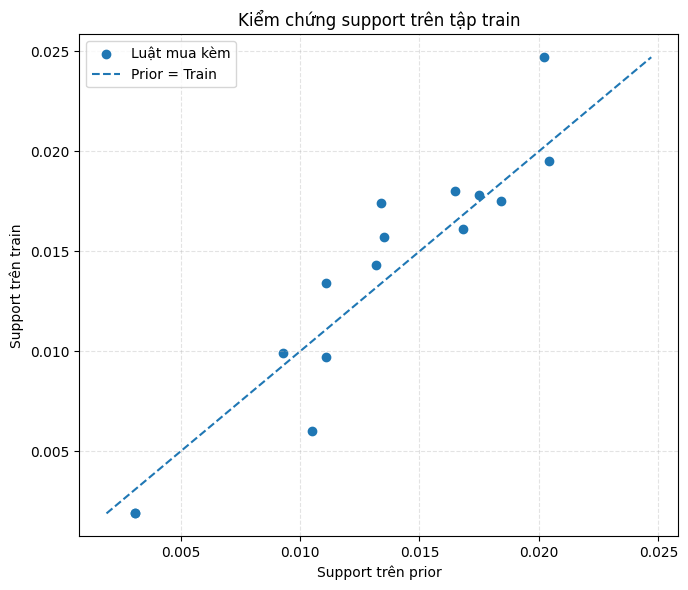

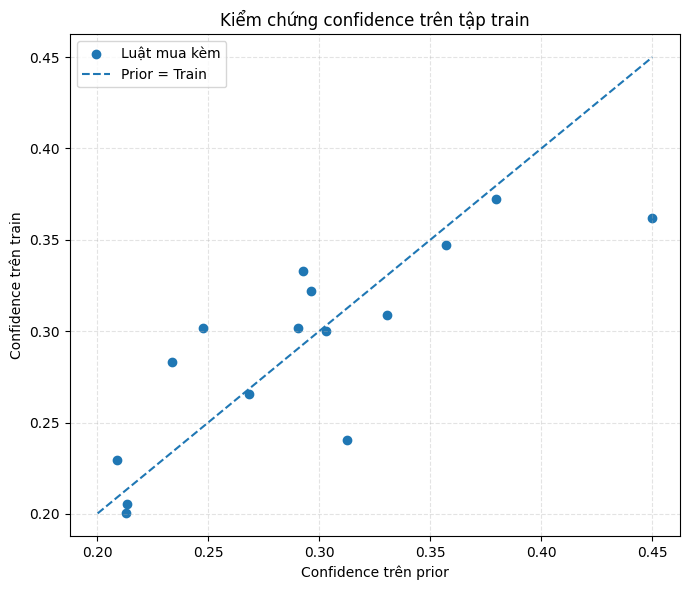

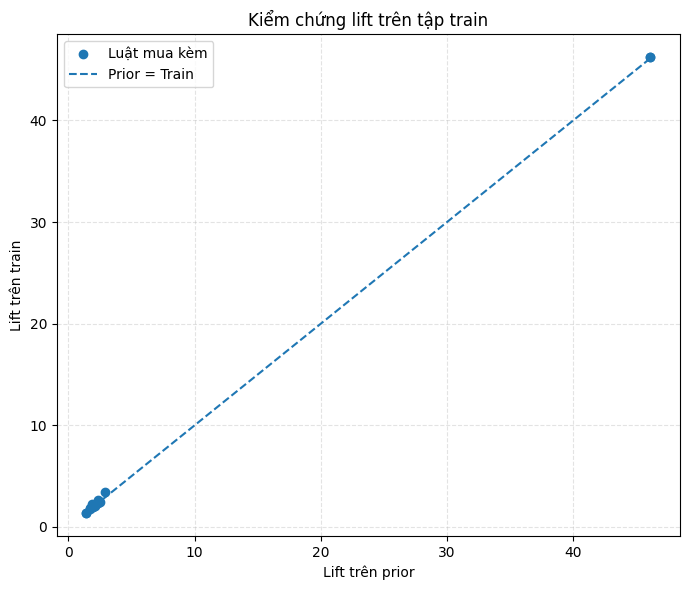

,Luật,Support trên prior,Support trên train,Chênh lệch support,Confidence trên prior,Confidence trên train,Chênh lệch confidence,Lift trên prior,Lift trên train,Chênh lệch lift
0,Total 2% Lowfat Greek Strained Yogurt With Blu...,0.0031,0.0019,0.0012,0.4499,0.3617,0.0883,46.0994,46.2268,0.1274
1,Total 2% with Strawberry Lowfat Greek Strained...,0.0031,0.0019,0.0012,0.3126,0.2405,0.0721,46.0994,46.2268,0.1274
2,Organic Hass Avocado → Bag of Organic Bananas,0.0204,0.0195,0.0009,0.2928,0.3328,0.0400,2.3775,2.6922,0.3147
3,Organic Strawberries → Bag of Organic Bananas,0.0202,0.0247,0.0046,0.2338,0.2832,0.0494,1.8984,2.2910,0.3927
4,Organic Avocado → Banana,0.0175,0.0178,0.0004,0.3029,0.2999,0.0030,1.9684,1.9999,0.0315
5,Organic Strawberries → Banana,0.0184,0.0175,0.0009,0.2131,0.2003,0.0128,1.3848,1.3360,0.0488
6,Organic Baby Spinach → Banana,0.0168,0.0161,0.0007,0.2135,0.2052,0.0083,1.3875,1.3686,0.0188
7,Organic Baby Spinach → Bag of Organic Bananas,0.0165,0.0180,0.0015,0.2092,0.2294,0.0202,1.6986,1.8558,0.1571
8,Strawberries → Banana,0.0135,0.0157,0.0022,0.2905,0.3018,0.0113,1.8881,2.0127,0.1246
9,Organic Raspberries → Bag of Organic Bananas,0.0132,0.0143,0.0011,0.2963,0.3219,0.0256,2.4056,2.6036,0.1980


In [5]:
validation = improver.validate_on_train(
    weighted_rules.head(CFG.top_n),
    prior_items,
    train_items,
)

validation_report = validation.copy()
validation_report["Luật"] = validation_report.apply(
    formatter.rule_text,
    axis=1,
)
validation_report = validation_report.rename(
    columns={
        "prior_support": "Support trên prior",
        "train_support": "Support trên train",
        "support_gap": "Chênh lệch support",
        "prior_confidence": "Confidence trên prior",
        "train_confidence": "Confidence trên train",
        "confidence_gap": "Chênh lệch confidence",
        "prior_lift": "Lift trên prior",
        "train_lift": "Lift trên train",
        "lift_gap": "Chênh lệch lift",
    }
)
validation_report = validation_report[
    [
        "Luật",
        "Support trên prior",
        "Support trên train",
        "Chênh lệch support",
        "Confidence trên prior",
        "Confidence trên train",
        "Chênh lệch confidence",
        "Lift trên prior",
        "Lift trên train",
        "Chênh lệch lift",
    ]
]

save_csv(validation_report, PATHS.table_file("rule_validation.csv"))

PLOT.scatter_reference(
    validation_report,
    x="Support trên prior",
    y="Support trên train",
    title="Kiểm chứng support trên tập train",
    filename="support_validation.png",
)

PLOT.scatter_reference(
    validation_report,
    x="Confidence trên prior",
    y="Confidence trên train",
    title="Kiểm chứng confidence trên tập train",
    filename="confidence_validation.png",
)

PLOT.scatter_reference(
    validation_report,
    x="Lift trên prior",
    y="Lift trên train",
    title="Kiểm chứng lift trên tập train",
    filename="lift_validation.png",
)

validation_report